In [16]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.612418,1.748607,-1.598402,-0.763164,1.263363,0
1,-1.337692,-1.271515,-1.013873,-0.214559,2.288814,0
2,-2.356341,-0.561125,-1.756209,1.445824,1.144702,0
3,0.601255,1.788404,-0.633440,-0.418743,-0.141065,0
4,2.685956,0.314141,-0.441741,0.537847,0.864001,0


In [5]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [11]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [ ]:

# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [17]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Raj\AppData\Local\Temp\ipykernel_32516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [18]:

df2 = combined_sampling(df,0.5,0.5)

C:\Users\Raj\AppData\Local\Temp\ipykernel_32516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [19]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Raj\AppData\Local\Temp\ipykernel_32516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [20]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col5', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')
Index(['col5', 'col2', 'target'], dtype='object')


In [21]:
df3

,col5,col2,target
59,1.679781,0.984769,0
6,1.061232,0.330017,0
54,1.624575,2.411743,1
61,0.508559,2.521609,1
84,1.783622,-1.203934,1
18,0.377715,2.713304,1
0,1.263363,1.748607,0
67,0.609544,1.624645,0
53,0.688546,-0.700613,0
42,3.186832,3.115336,1


In [22]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [23]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [24]:

from sklearn.tree import plot_tree

[Text(0.3076923076923077, 0.9583333333333334, 'x[1] <= 0.299\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.15384615384615385, 0.875, 'x[1] <= -1.482\ngini = 0.346\nsamples = 18\nvalue = [14, 4]'),
 Text(0.07692307692307693, 0.7916666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.23076923076923078, 0.7916666666666666, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.46153846153846156, 0.875, 'x[1] <= 0.513\ngini = 0.451\nsamples = 32\nvalue = [11, 21]'),
 Text(0.38461538461538464, 0.7916666666666666, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.5384615384615384, 0.7916666666666666, 'x[1] <= 0.698\ngini = 0.493\nsamples = 25\nvalue = [11, 14]'),
 Text(0.46153846153846156, 0.7083333333333334, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6153846153846154, 0.7083333333333334, 'x[0] <= -0.182\ngini = 0.463\nsamples = 22\nvalue = [8, 14]'),
 Text(0.5384615384615384, 0.625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6923076923076923, 0.625, 

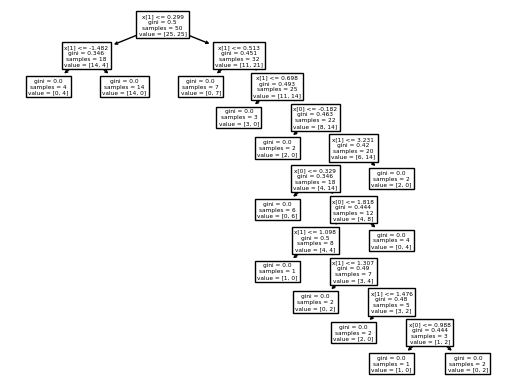

In [25]:
plot_tree(clf1)

[Text(0.6, 0.9375, 'x[0] <= 1.64\ngini = 0.487\nsamples = 50\nvalue = [29, 21]'),
 Text(0.5, 0.8125, 'x[1] <= 1.156\ngini = 0.427\nsamples = 42\nvalue = [29, 13]'),
 Text(0.2, 0.6875, 'x[0] <= 0.518\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.1, 0.5625, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.3, 0.5625, 'x[0] <= 0.8\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.2, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.4375, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.8, 0.6875, 'x[0] <= -0.005\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.7, 0.5625, 'x[0] <= -2.067\ngini = 0.49\nsamples = 14\nvalue = [8, 6]'),
 Text(0.6, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.4375, 'x[0] <= -0.485\ngini = 0.496\nsamples = 11\nvalue = [5, 6]'),
 Text(0.7, 0.3125, 'x[0] <= -1.284\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.6, 0.1875, 'x[0] <= -1.882\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.5, 0.062

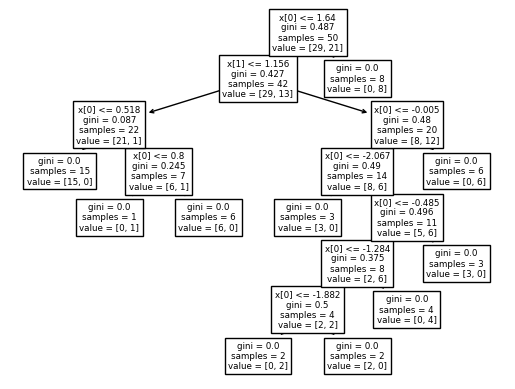

In [26]:
plot_tree(clf2)

[Text(0.717391304347826, 0.9285714285714286, 'x[1] <= 2.251\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.5652173913043478, 0.7857142857142857, 'x[1] <= 1.623\ngini = 0.488\nsamples = 38\nvalue = [22, 16]'),
 Text(0.391304347826087, 0.6428571428571429, 'x[1] <= 0.55\ngini = 0.494\nsamples = 27\nvalue = [12, 15]'),
 Text(0.21739130434782608, 0.5, 'x[0] <= 1.18\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.13043478260869565, 0.35714285714285715, 'x[0] <= 0.532\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.08695652173913043, 0.21428571428571427, 'x[0] <= -0.08\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.043478260869565216, 0.07142857142857142, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.13043478260869565, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17391304347826086, 0.21428571428571427, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30434782608695654, 0.35714285714285715, 'x[0] <= 2.188\ngini = 0.48\nsamples

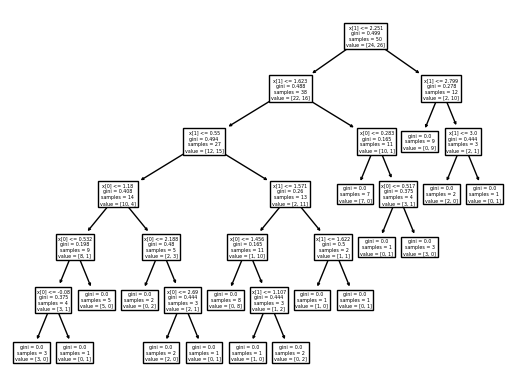

In [27]:
plot_tree(clf3)

In [28]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Raj\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [29]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Raj\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [30]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Raj\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [47]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
72,-0.000876,1.621878,-0.279277,-1.737399,0.474978,0
71,1.450202,0.301148,-1.404533,1.518311,1.207547,1
46,0.643528,-0.108287,-0.386540,2.845364,2.162743,1
44,-0.729558,0.396391,-0.142429,0.114195,-0.726763,0
15,-3.476533,0.929114,-0.805513,-3.179973,1.381979,0
11,-0.689282,-0.497590,-0.936167,-0.520536,2.595993,0
51,-2.876650,0.768879,-1.256266,-1.359501,-0.286479,0
38,1.013760,0.770598,-0.931429,0.890691,0.468953,1
0,-1.612418,1.748607,-1.598402,-0.763164,1.263363,0
48,0.060449,-1.506786,-1.133003,2.851714,1.508111,1


In [32]:

df1.sample(14,replace=True)

,col2,col5,target
96,2.409995,0.568106,0
83,1.497839,0.412856,1
67,1.624645,0.609544,0
89,2.884820,-0.522837,0
77,0.283980,1.299404,1
54,2.411743,1.624575,1
26,1.622321,1.516054,1
36,1.263666,3.058661,1
77,0.283980,1.299404,1
41,1.983241,0.424666,1
